# 5. Regression with fuzzy rules

`BaseFuzzyRulesRegressor` learns Type-1 rules for a continuous target with
the same genetic search as the classifier. Two consequent types are
available:

- **crisp** (Takagi-Sugeno of order zero): each rule outputs a number, and
  the prediction is the firing-weighted average of the rules that fire;
- **fuzzy** (Mamdani): each rule outputs a fuzzy set of the target, and the
  prediction is the centroid of the aggregated output.

The data is the California housing set from scikit-learn, downloaded on
first use and cached in your home directory. We subsample it so the
notebook runs in a minute.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from ex_fuzzy import BaseFuzzyRulesRegressor

housing = fetch_california_housing(as_frame=True)
X = housing.frame.drop(columns='MedHouseVal')
y = housing.frame['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=3000, test_size=2000, random_state=0)
X_train.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,3.87,28.70,5.42,1.10,1437.69,2.93,35.66,-119.59
std,1.90,12.52,2.07,0.35,1138.98,0.81,2.13,1.99
min,0.50,1.00,1.47,0.50,9.00,0.69,32.57,-124.30
25%,2.56,18.00,4.41,1.01,798.00,2.44,33.93,-121.79
50%,3.54,29.00,5.24,1.05,1165.50,2.83,34.28,-118.52
75%,4.75,37.00,6.06,1.10,1745.00,3.29,37.73,-118.04
max,15.00,52.00,52.69,8.86,16305.00,18.44,41.84,-114.58


## Crisp consequents

In [2]:
crisp = BaseFuzzyRulesRegressor(nRules=12, nAnts=3, consequent_type='crisp')
crisp.fit(X_train, y_train, n_gen=30, pop_size=30, random_state=0)
print(f'crisp   R2 train {crisp.score(X_train, y_train):.3f}  test {crisp.score(X_test, y_test):.3f}')
crisp.print_rules()

crisp   R2 train 0.313  test 0.293
Rule 1: IF AveOccup IS Medium AND Latitude IS Low THEN output = 2.2355
Rule 2: IF MedInc IS Low AND AveBedrms IS Low THEN output = 0.8290
Rule 3: IF MedInc IS Low THEN output = 1.7020
Rule 4: IF HouseAge IS Low AND Latitude IS High THEN output = 2.1870
Rule 5: IF MedInc IS Low AND AveRooms IS Medium THEN output = 0.6350
Rule 6: IF MedInc IS Medium AND AveOccup IS Low THEN output = 2.6720
Rule 7: IF MedInc IS Low AND AveRooms IS Low AND Latitude IS Low THEN output = 1.2170
Rule 8: IF HouseAge IS Medium AND AveOccup IS Low THEN output = 3.7390
Rule 9: IF MedInc IS Medium THEN output = 1.8960
Rule 10: IF MedInc IS Low THEN output = 1.2170
Rule 11: IF MedInc IS Medium AND HouseAge IS Low THEN output = 1.5565
Rule 12: IF MedInc IS Low THEN output = 1.0230



## Mamdani consequents

With `consequent_type="fuzzy"` the target is partitioned into fuzzy sets too
(`n_output_lvs` of them), and each rule points at one of them. The rules
read like the classification ones, at the cost of some precision.

In [3]:
mamdani = BaseFuzzyRulesRegressor(nRules=12, nAnts=3, consequent_type='fuzzy', n_output_lvs=5)
mamdani.fit(X_train, y_train, n_gen=30, pop_size=30, random_state=0)
print(f'mamdani R2 train {mamdani.score(X_train, y_train):.3f}  test {mamdani.score(X_test, y_test):.3f}')
mamdani.print_rules()

mamdani R2 train 0.355  test 0.375
Rule 1: IF MedInc IS Low AND AveOccup IS Medium AND Latitude IS Low THEN output IS Output_2
Rule 2: IF HouseAge IS Low AND AveBedrms IS Low THEN output IS Output_0
Rule 3: IF HouseAge IS Low THEN output IS Output_0
Rule 4: IF MedInc IS High THEN output IS Output_1
Rule 5: IF MedInc IS Low AND AveRooms IS Low AND Latitude IS Low THEN output IS Output_0
Rule 6: IF MedInc IS Low AND HouseAge IS Low AND Population IS Low THEN output IS Output_3
Rule 7: IF MedInc IS Low AND Population IS Low THEN output IS Output_3
Rule 8: IF HouseAge IS Low AND AveRooms IS Low AND Population IS Low THEN output IS Output_0
Rule 9: IF MedInc IS Low AND Population IS Medium THEN output IS Output_3
Rule 10: IF MedInc IS Medium AND AveBedrms IS Low THEN output IS Output_2
Rule 11: IF HouseAge IS Low AND AveBedrms IS Low AND AveOccup IS Medium THEN output IS Output_3
Rule 12: IF MedInc IS Low AND HouseAge IS Medium AND AveBedrms IS High THEN output IS Output_0



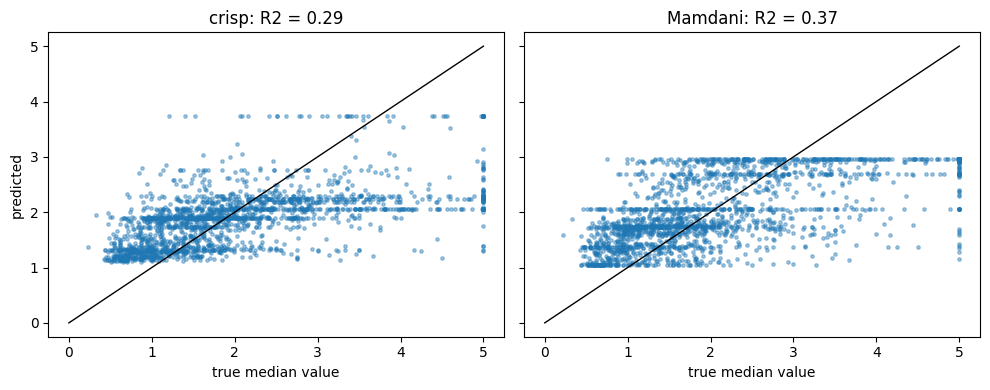

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for axis, model, name in zip(axes, (crisp, mamdani), ('crisp', 'Mamdani')):
    axis.scatter(y_test, model.predict(X_test), s=6, alpha=0.4)
    axis.plot([0, 5], [0, 5], color='black', linewidth=1)
    axis.set_title(f'{name}: R2 = {model.score(X_test, y_test):.2f}')
    axis.set_xlabel('true median value')
axes[0].set_ylabel('predicted')
plt.tight_layout()

## What happens underneath: inference by hand

A regression rule base is a `RuleBaseT1` (or `RuleBaseT2`) whose rules point
at the fuzzy sets of a consequent variable. The classic restaurant tip
example makes the mechanics visible: two inputs, one output, three rules.

In [5]:
from ex_fuzzy import fuzzy_sets as fs, rules

food = fs.fuzzyVariable('food', [fs.FS('bad', [0, 0, 3, 5], [0, 10]),
                                 fs.FS('ok', [3, 5, 5, 7], [0, 10]),
                                 fs.FS('great', [5, 7, 10, 10], [0, 10])])
service = fs.fuzzyVariable('service', [fs.FS('poor', [0, 0, 3, 5], [0, 10]),
                                       fs.FS('fine', [3, 5, 5, 7], [0, 10]),
                                       fs.FS('excellent', [5, 7, 10, 10], [0, 10])])
tip = fs.fuzzyVariable('tip', [fs.FS('low', [0, 0, 5, 10], [0, 25]),
                               fs.FS('medium', [5, 12, 12, 20], [0, 25]),
                               fs.FS('high', [15, 20, 25, 25], [0, 25])])

# antecedents are label indexes per input (-1 means "don't care"); the consequent is a tip label
rule_list = [rules.RuleSimple([0, 0], 0),    # bad food AND poor service -> low tip
             rules.RuleSimple([-1, 1], 1),   # fine service -> medium tip
             rules.RuleSimple([2, 2], 2)]    # great food AND excellent service -> high tip
tipping = rules.RuleBaseT1([food, service], rule_list, tip)

situations = np.array([[2.0, 2.0], [6.0, 5.0], [9.5, 9.0]])
pd.DataFrame({'food': situations[:, 0], 'service': situations[:, 1], 'tip': tipping.inference(situations).round(2)})

,food,service,tip
0,2.0,2.0,3.88
1,6.0,5.0,12.33
2,9.5,9.0,21.10


`inference` computes the firing strength of every rule (the product of the
antecedent memberships), then the centroid of the consequents weighted by
those strengths. The interval Type-2 version, `RuleBaseT2`, does the same
with a Karnik-Mendel type reduction.